In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from src.feature_engineering import (
    make_feature_engineering_experiments,
    run_feature_engineering_experiments,
    plot_feature_engineering_results,
)

In [3]:
df = pd.read_csv('../data/raw/diamonds.csv', index_col=0)

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
)

In [5]:
experiments = make_feature_engineering_experiments()

len(experiments)

9

In [6]:
fe_results = run_feature_engineering_experiments(
    data=train_df,
    experiments=experiments,
    target="price",
    n_jobs=2,
)

fe_results

,experiment,description,mean_rmse,std_rmse,delta_vs_baseline
7,geometry_without_xyz_plus_ordinal_clarity,"Use geometry features without raw x, y, z and ...",551.668653,10.058521,-8.838584
6,geometry_without_xyz,"Use geometry features and remove raw x, y, z.",556.445556,8.348005,-4.061680
5,ordinal_clarity,Use ordinal encoding for clarity instead of on...,556.524539,10.835462,-3.982697
2,geometry_features,"Add volume, base_area and xy_ratio.",557.504197,10.632486,-3.003039
1,zero_dimensions_to_nan,"Replace rows where x, y, z are all zero with NaN.",560.234438,10.841662,-0.272798
3,zero_dimensions_plus_geometry,"Replace zero dimensions with NaN, then add geo...",560.337796,8.860923,-0.169441
0,baseline_hgbr,Baseline HistGradientBoostingRegressor without...,560.507236,9.208660,0.000000
4,log_carat,Add log1p(carat) as an additional feature.,560.507236,9.208660,0.000000
8,log_target,Train model on log1p(price) using TransformedT...,580.654599,21.632443,20.147363


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Feature engineering experiments'}, xlabel='CV RMSE', ylabel='Experiment'>)

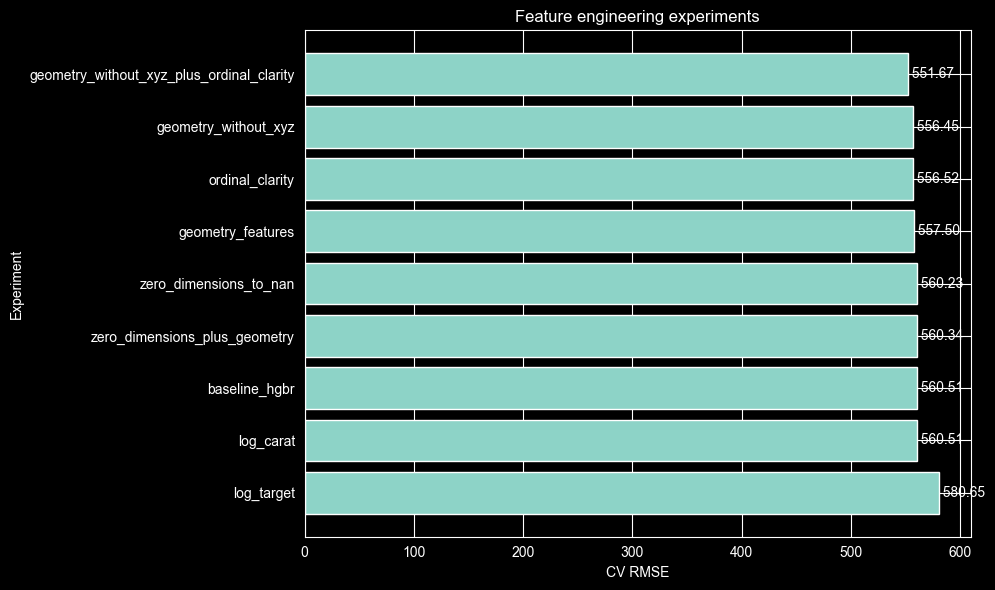

In [7]:
plot_feature_engineering_results(fe_results)

In [8]:
fe_results.sort_values("mean_rmse", ascending=True)

,experiment,description,mean_rmse,std_rmse,delta_vs_baseline
7,geometry_without_xyz_plus_ordinal_clarity,"Use geometry features without raw x, y, z and ...",551.668653,10.058521,-8.838584
6,geometry_without_xyz,"Use geometry features and remove raw x, y, z.",556.445556,8.348005,-4.061680
5,ordinal_clarity,Use ordinal encoding for clarity instead of on...,556.524539,10.835462,-3.982697
2,geometry_features,"Add volume, base_area and xy_ratio.",557.504197,10.632486,-3.003039
1,zero_dimensions_to_nan,"Replace rows where x, y, z are all zero with NaN.",560.234438,10.841662,-0.272798
3,zero_dimensions_plus_geometry,"Replace zero dimensions with NaN, then add geo...",560.337796,8.860923,-0.169441
0,baseline_hgbr,Baseline HistGradientBoostingRegressor without...,560.507236,9.208660,0.000000
4,log_carat,Add log1p(carat) as an additional feature.,560.507236,9.208660,0.000000
8,log_target,Train model on log1p(price) using TransformedT...,580.654599,21.632443,20.147363
